In [ ]:
from v2_data_preparation import process_insitu
from scipy.stats import zscore
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [962]:
def process_s1_orbits(filepath, window="30D"):
    """Lee y procesa series temporales de Sentinel-1 separando por órbita.

    Parámetros:
    -----------
    filepath : str
        Ruta al archivo CSV exportado desde GEE.
    window : str o int
        Tamaño de la ventana para el suavizado rolling (ej. '30D', 5).

    Retorna:
    --------
    tuple (pd.DataFrame, pd.DataFrame)
        (ascending_df, descending_df) procesados e indexados por fecha.
    """
    # 1. Cargar archivo y parsear fechas
    df = pd.read_csv(filepath)
    df["Timestamps"] = pd.to_datetime(df["Timestamps"], format="%Y-%m-%d")

    def _clean_and_smooth(sub_df):
        # Limpieza, ordenamiento e indexación
        cleaned = (
            sub_df.drop(columns=["Orbit"])
            .drop_duplicates(subset=["Timestamps"], keep="first")
            .dropna()
            .set_index("Timestamps")
            .sort_index()
        )

        # Suavizado de retrodispersión
        cleaned["VV_smooth"] = (
            cleaned["VV"].rolling(window=window, min_periods=1).mean()
        )
        cleaned["VH_smooth"] = (
            cleaned["VH"].rolling(window=window, min_periods=1).mean()
        )

        return cleaned

    # 2. Separar por órbita y aplicar procesamiento modular
    is_ascending = df["Orbit"] == "ASCENDING"

    ascending_df = _clean_and_smooth(df[is_ascending])
    descending_df = _clean_and_smooth(df[~is_ascending])

    return ascending_df, descending_df


def prepare_and_correlate(df1, df2, df1_vars = None, df2_vars = None, corr_method='pearson', min_obs = 30):
    """
    Filters data by selected variables, merges on datetime index, and calculates correlation.
    """
    # filter columns based on user selection
    if df1_vars:
        df1 = df1[df1_vars]
    if df2_vars:
        df2 = df2[df2_vars]

    # merge both datasets using their datetime index
    merged_data = pd.merge(
        df1, 
        df2, 
        left_index=True, 
        right_index=True, 
        how='inner'
    )

    # filter columns without minimum number of observations
    merged_data = merged_data.dropna(axis=1, thresh=min_obs)

    # calculate the correlation matrix
    correlation_matrix = merged_data.corr(
        method=corr_method,
        #min_periods=min_obs
    )
    
    return correlation_matrix, merged_data

In [963]:
mono_db = '../data/processed/satellites/SDH1_S1_2024-06_2026-09_Mono_Lee_12x12_dB.csv'
mono_linear = '../data/processed/satellites/SDH1_S1_2024-06_2026-09_Mono_Lee_12x12_linear.csv'

multi_db = '../data/processed/satellites/SDH1_S1_2024-06_2026-09_Multi_Lee_7x7_10img_dB.csv'
multi_linear = '../data/processed/satellites/SDH1_S1_2024-06_2026-09_Multi_Lee_7x7_10img_linear.csv'

In [964]:
insitu = process_insitu(
    filepath='../data/processed/in-situ/SDH1_daily-insitu-data.csv',
    start_date='2024-06-01',
    end_date='2026-05-14',
    cols_to_keep=['SDH1PS01_gw-depth_m', 'TEROS12-05cm_water-content_m3m3', 'TEROS12-15cm_water-content_m3m3', 'ATMOS41_precipitation_mm'],
    outlier_threshold=3,
    ignore_outliers_cols=['ATMOS41_precipitation_mm']
)

In [965]:
mono_db_asc, mono_db_desc = process_s1_orbits(mono_db, window='10D')
mono_lin_asc, mono_lin_desc = process_s1_orbits(mono_linear, window='10D')

multi_db_asc, multi_db_desc = process_s1_orbits(multi_db, window='10D')
multi_lin_asc, multi_lin_desc = process_s1_orbits(multi_linear, window='10D')

### Analisis de correlaciones: mono y multi

In [966]:
corr_mono_db_asc, merged_mono_db_a = prepare_and_correlate(insitu, mono_db_asc, corr_method='spearman')
corr_mono_db_desc, merged_mono_db_d = prepare_and_correlate(insitu, mono_db_desc, corr_method='spearman')

corr_mono_lin_asc, merged_mono_lin_a = prepare_and_correlate(insitu, mono_lin_asc, corr_method='spearman')
corr_mono_lin_desc, merged_mono_lin_d = prepare_and_correlate(insitu, mono_lin_desc, corr_method='spearman')

In [967]:
corr_multi_db_asc, merged_multi_a = prepare_and_correlate(insitu, multi_db_asc, corr_method='spearman')
corr_multi_db_desc, merged_multi_d = prepare_and_correlate(insitu, multi_db_desc, corr_method='spearman')

Con Spearman, las correlaciones con dB y linear dan el mismo resultado en las series no suavizadas. 

In [968]:
corr_mono_db_asc

,SDH1PS01_gw-depth_m,TEROS12-05cm_water-content_m3m3,TEROS12-15cm_water-content_m3m3,ATMOS41_precipitation_mm,VV,VH,VV_smooth,VH_smooth
SDH1PS01_gw-depth_m,1.000000,0.593138,0.803585,-0.247262,-0.031364,-0.252647,-0.063780,-0.336362
TEROS12-05cm_water-content_m3m3,0.593138,1.000000,0.729275,-0.099809,0.439927,0.231426,0.376841,0.210342
TEROS12-15cm_water-content_m3m3,0.803585,0.729275,1.000000,-0.518958,-0.102775,-0.293634,-0.127490,-0.365291
ATMOS41_precipitation_mm,-0.247262,-0.099809,-0.518958,1.000000,0.332058,0.487939,0.339691,0.531553
VV,-0.031364,0.439927,-0.102775,0.332058,1.000000,0.666165,0.968913,0.704388
VH,-0.252647,0.231426,-0.293634,0.487939,0.666165,1.000000,0.680355,0.937717
VV_smooth,-0.063780,0.376841,-0.127490,0.339691,0.968913,0.680355,1.000000,0.732194
VH_smooth,-0.336362,0.210342,-0.365291,0.531553,0.704388,0.937717,0.732194,1.000000


In [969]:
corr_mono_db_desc

,SDH1PS01_gw-depth_m,TEROS12-05cm_water-content_m3m3,TEROS12-15cm_water-content_m3m3,ATMOS41_precipitation_mm,VV,VH,VV_smooth,VH_smooth
SDH1PS01_gw-depth_m,1.000000,0.640363,0.763996,-0.178363,-0.139112,-0.100009,-0.291123,-0.229829
TEROS12-05cm_water-content_m3m3,0.640363,1.000000,0.732838,-0.175581,0.238076,0.109061,0.256621,0.083082
TEROS12-15cm_water-content_m3m3,0.763996,0.732838,1.000000,-0.471696,-0.308018,-0.270263,-0.481832,-0.435105
ATMOS41_precipitation_mm,-0.178363,-0.175581,-0.471696,1.000000,0.382180,0.310791,0.597991,0.485865
VV,-0.139112,0.238076,-0.308018,0.382180,1.000000,0.524129,0.780954,0.549694
VH,-0.100009,0.109061,-0.270263,0.310791,0.524129,1.000000,0.528308,0.719292
VV_smooth,-0.291123,0.256621,-0.481832,0.597991,0.780954,0.528308,1.000000,0.717404
VH_smooth,-0.229829,0.083082,-0.435105,0.485865,0.549694,0.719292,0.717404,1.000000


In [970]:
corr_multi_db_asc

,SDH1PS01_gw-depth_m,TEROS12-05cm_water-content_m3m3,TEROS12-15cm_water-content_m3m3,ATMOS41_precipitation_mm,VV,VH,VV_smooth,VH_smooth
SDH1PS01_gw-depth_m,1.000000,0.593138,0.803585,-0.247262,-0.101502,-0.340887,-0.135723,-0.393046
TEROS12-05cm_water-content_m3m3,0.593138,1.000000,0.729275,-0.099809,0.410141,0.209840,0.368474,0.175201
TEROS12-15cm_water-content_m3m3,0.803585,0.729275,1.000000,-0.518958,-0.165897,-0.371022,-0.191105,-0.421739
ATMOS41_precipitation_mm,-0.247262,-0.099809,-0.518958,1.000000,0.353632,0.513004,0.354818,0.530319
VV,-0.101502,0.410141,-0.165897,0.353632,1.000000,0.675489,0.951716,0.713165
VH,-0.340887,0.209840,-0.371022,0.513004,0.675489,1.000000,0.693506,0.956473
VV_smooth,-0.135723,0.368474,-0.191105,0.354818,0.951716,0.693506,1.000000,0.741791
VH_smooth,-0.393046,0.175201,-0.421739,0.530319,0.713165,0.956473,0.741791,1.000000


In [971]:
corr_multi_db_desc

,SDH1PS01_gw-depth_m,TEROS12-05cm_water-content_m3m3,TEROS12-15cm_water-content_m3m3,ATMOS41_precipitation_mm,VV,VH,VV_smooth,VH_smooth
SDH1PS01_gw-depth_m,1.000000,0.640363,0.763996,-0.178363,-0.076073,-0.115419,-0.172112,-0.260113
TEROS12-05cm_water-content_m3m3,0.640363,1.000000,0.732838,-0.175581,0.196312,0.093067,0.295284,0.058425
TEROS12-15cm_water-content_m3m3,0.763996,0.732838,1.000000,-0.471696,-0.236003,-0.275693,-0.372573,-0.453098
ATMOS41_precipitation_mm,-0.178363,-0.175581,-0.471696,1.000000,0.281367,0.288989,0.542167,0.474844
VV,-0.076073,0.196312,-0.236003,0.281367,1.000000,0.471596,0.726376,0.452397
VH,-0.115419,0.093067,-0.275693,0.288989,0.471596,1.000000,0.454961,0.692057
VV_smooth,-0.172112,0.295284,-0.372573,0.542167,0.726376,0.454961,1.000000,0.617903
VH_smooth,-0.260113,0.058425,-0.453098,0.474844,0.452397,0.692057,0.617903,1.000000


### Visualizaciones: db y linear

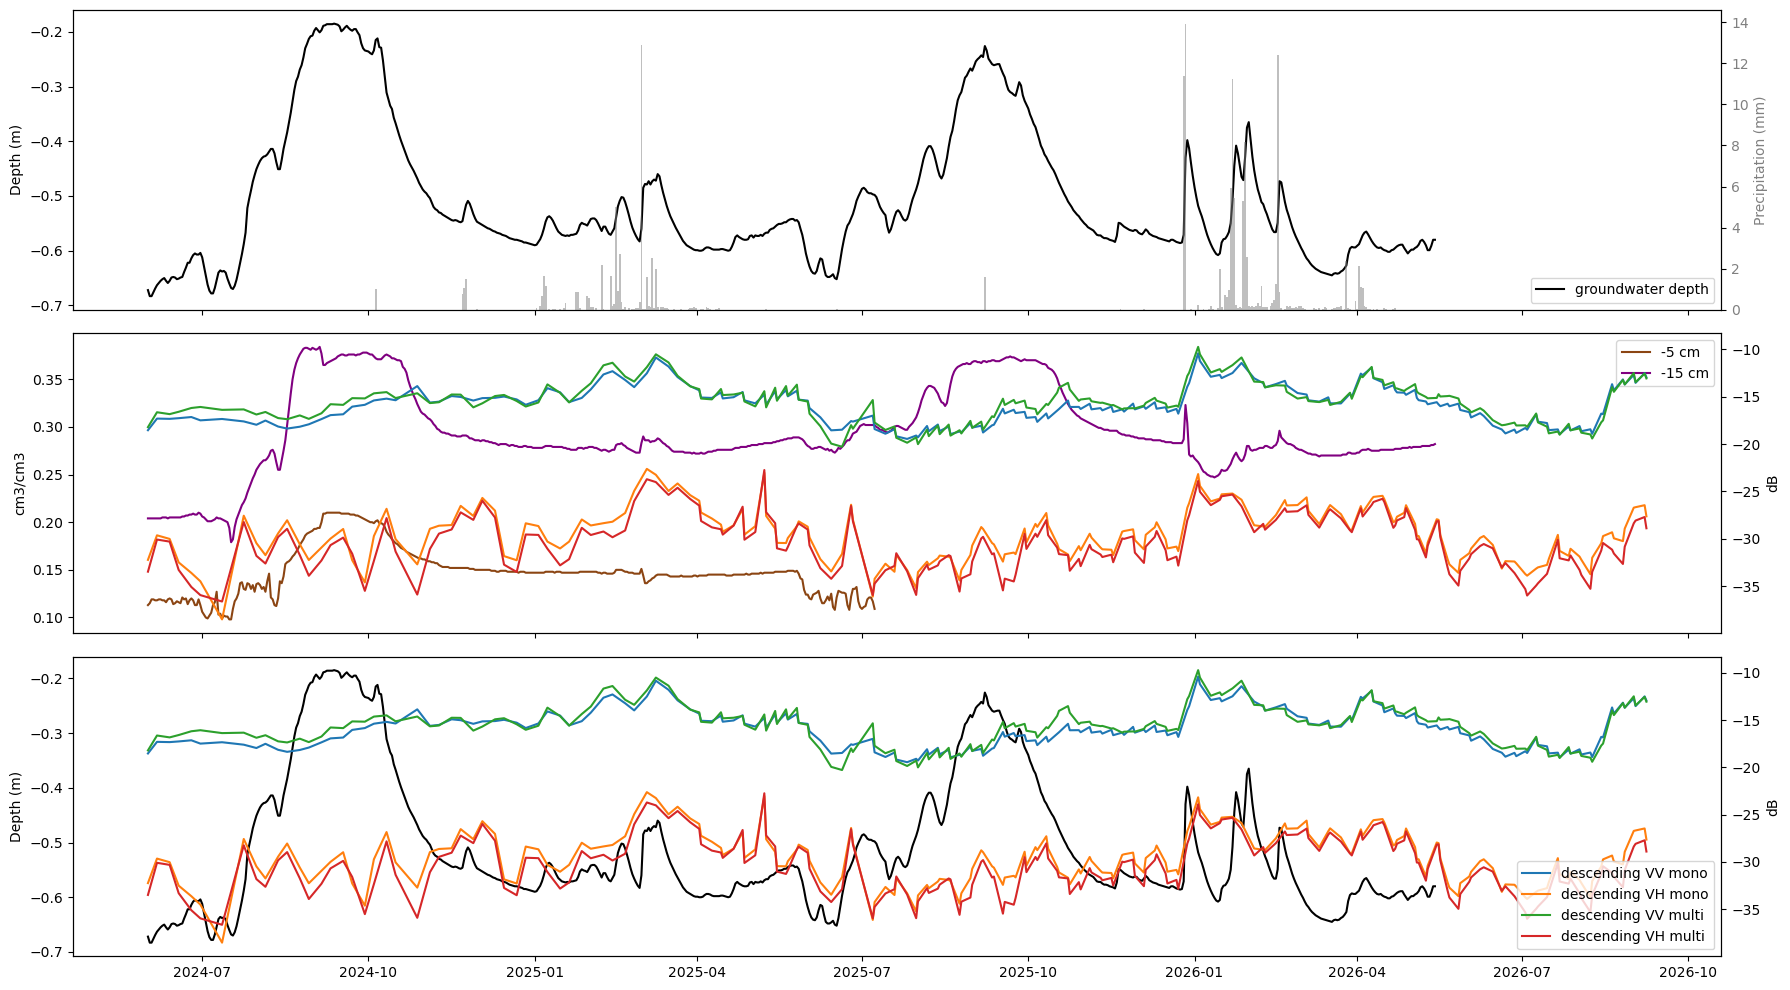

In [972]:
# Figure
fig, (ax1, ax2, ax5) = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

# Plot superior
ax1.plot(insitu.index, insitu['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax1.set_ylabel('Depth (m)')
ax1.legend(loc='lower right')

ax3 = ax1.twinx()
ax3.bar(insitu.index, insitu['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

# Plot inferior
ax2.plot(insitu.index, insitu['TEROS12-05cm_water-content_m3m3'], label='-5 cm', c='saddlebrown', alpha=1)
ax2.plot(insitu.index, insitu['TEROS12-15cm_water-content_m3m3'], label='-15 cm', c='purple', alpha=1)
ax2.set_ylabel('cm3/cm3')
ax2.legend(loc='upper right')

ax4 = ax2.twinx()
ax4.plot(mono_db_desc.index, mono_db_desc['VV_smooth'], label = 'descending VV mono')
ax4.plot(mono_db_desc.index, mono_db_desc['VH_smooth'], label = 'descending VH mono')
ax4.plot(multi_db_desc.index, multi_db_desc['VV_smooth'], label = 'descending VV multi')
ax4.plot(multi_db_desc.index, multi_db_desc['VH_smooth'], label = 'descending VH multi')
ax4.set_ylabel('dB')


# Plot mas inferior
ax5.plot(insitu.index, insitu['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax5.set_ylabel('Depth (m)')

ax6 = ax5.twinx()
ax6.plot(mono_db_desc.index, mono_db_desc['VV_smooth'], label = 'descending VV mono')
ax6.plot(mono_db_desc.index, mono_db_desc['VH_smooth'], label = 'descending VH mono')
ax6.plot(multi_db_desc.index, multi_db_desc['VV_smooth'], label = 'descending VV multi')
ax6.plot(multi_db_desc.index, multi_db_desc['VH_smooth'], label = 'descending VH multi')
ax6.set_ylabel('dB')
ax6.legend(loc='lower right')

plt.tight_layout()
plt.show()

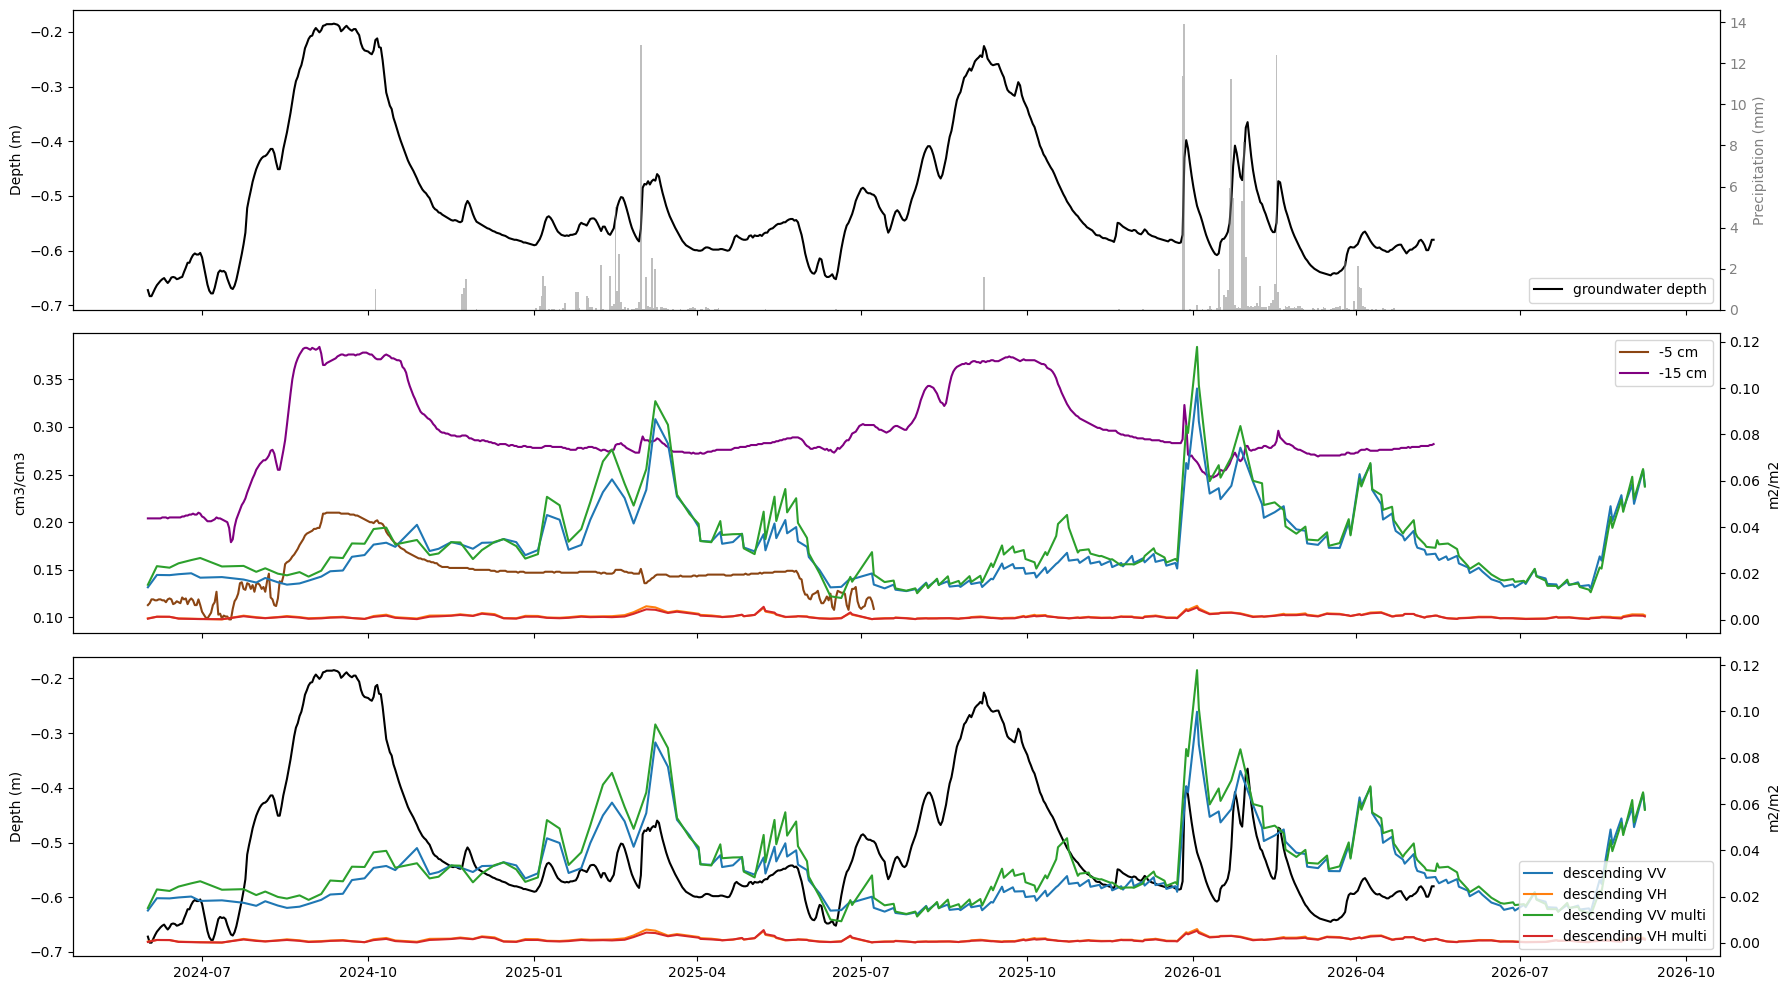

In [973]:
# Figure
fig, (ax1, ax2, ax5) = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

# Plot superior
ax1.plot(insitu.index, insitu['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax1.set_ylabel('Depth (m)')
ax1.legend(loc='lower right')

ax3 = ax1.twinx()
ax3.bar(insitu.index, insitu['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

# Plot inferior
ax2.plot(insitu.index, insitu['TEROS12-05cm_water-content_m3m3'], label='-5 cm', c='saddlebrown', alpha=1)
ax2.plot(insitu.index, insitu['TEROS12-15cm_water-content_m3m3'], label='-15 cm', c='purple', alpha=1)
ax2.set_ylabel('cm3/cm3')
ax2.legend(loc='upper right')

ax4 = ax2.twinx()
ax4.plot(mono_lin_desc.index, mono_lin_desc['VV_smooth'], label = 'descending VV')
ax4.plot(mono_lin_desc.index, mono_lin_desc['VH_smooth'], label = 'descending VH')
ax4.plot(multi_lin_desc.index, multi_lin_desc['VV_smooth'], label = 'descending VV multi')
ax4.plot(multi_lin_desc.index, multi_lin_desc['VH_smooth'], label = 'descending VH multi')
ax4.set_ylabel('m2/m2')


# Plot mas inferior
ax5.plot(insitu.index, insitu['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax5.set_ylabel('Depth (m)')

ax6 = ax5.twinx()
ax6.plot(mono_lin_desc.index, mono_lin_desc['VV_smooth'], label = 'descending VV')
ax6.plot(mono_lin_desc.index, mono_lin_desc['VH_smooth'], label = 'descending VH')
ax6.plot(multi_lin_desc.index, multi_lin_desc['VV_smooth'], label = 'descending VV multi')
ax6.plot(multi_lin_desc.index, multi_lin_desc['VH_smooth'], label = 'descending VH multi')
ax6.set_ylabel('m2/m2')
ax6.legend(loc='lower right')

plt.tight_layout()
plt.show()

Backscatter responde fuertemente a los input de lluvia y pareciera también responder suavemente a la subida del nivel en primavera.

### Analisis en subsets hidro-meteorologicos

En adelante usaré la colección descendente (más imágenes), el filtro mono (tincada) y dB (literatura)

In [974]:
merged_df = pd.merge(insitu, mono_db_desc, left_index=True, right_index=True, how='outer')

In [975]:
def subset_by_meteo(df, n_days = 1, min_pp = 0.0):
    """
    Subdivide un df en funcion de condiciones meteorologicas
    """
    # Establece condicion
    rained = df['ATMOS41_precipitation_mm'] > min_pp

    # Configura mascara para abarcar hasta n dias
    pp_mask = (
    rained.rolling(f'{n_days + 1}D').max().astype(bool)
    )

    # Divide los df con la mascara
    rain = df[pp_mask]
    no_rain = df[~pp_mask]

    return rain, no_rain

def subset_by_gw_depth(df, max_depth = -0.35):
    """
    Subdivide un df en funcion de la profundidad del nivel
    """
    # Establece condicion
    is_shallow = df['SDH1PS01_gw-depth_m'] >= max_depth

    # Divide los df segun la condicion
    shallow = df[is_shallow]
    deep = df[~is_shallow]

    return shallow, deep

#### Subsets de lluvia

In [976]:
rain_df, no_rain_df = subset_by_meteo(merged_df, n_days=5)

<Axes: >

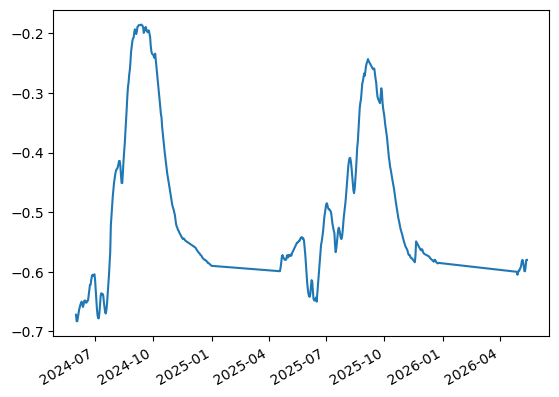

In [977]:
no_rain_df['SDH1PS01_gw-depth_m'].plot()

In [978]:
corr_rain = rain_df.corr(method='spearman', min_periods=30)
corr_no_rain = no_rain_df.corr(method='spearman', min_periods=30)

In [979]:
corr_no_rain

,SDH1PS01_gw-depth_m,TEROS12-05cm_water-content_m3m3,TEROS12-15cm_water-content_m3m3,ATMOS41_precipitation_mm,VV,VH,VV_smooth,VH_smooth
SDH1PS01_gw-depth_m,1.000000,0.788764,0.876504,NaN,-0.131092,0.030040,-0.320424,-0.099921
TEROS12-05cm_water-content_m3m3,0.788764,1.000000,0.859458,NaN,0.338892,0.211559,0.388334,0.216156
TEROS12-15cm_water-content_m3m3,0.876504,0.859458,1.000000,NaN,-0.070617,-0.004389,-0.218976,-0.124501
ATMOS41_precipitation_mm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VV,-0.131092,0.338892,-0.070617,NaN,1.000000,0.268123,0.722644,0.362943
VH,0.030040,0.211559,-0.004389,NaN,0.268123,1.000000,0.272333,0.594303
VV_smooth,-0.320424,0.388334,-0.218976,NaN,0.722644,0.272333,1.000000,0.543579
VH_smooth,-0.099921,0.216156,-0.124501,NaN,0.362943,0.594303,0.543579,1.000000


#### Subsets de gw depth

In [980]:
shallow_df, deep_df = subset_by_gw_depth(merged_df, max_depth=-0.36)

<Axes: >

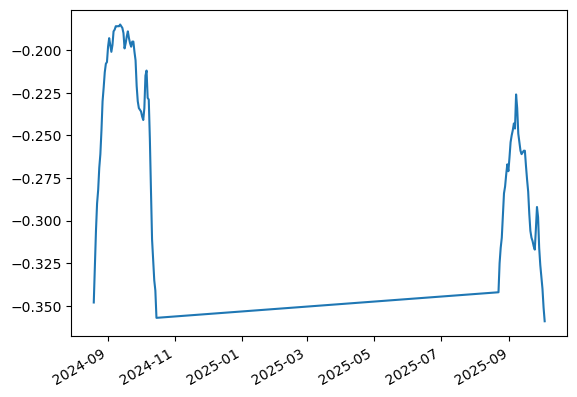

In [981]:
shallow_df['SDH1PS01_gw-depth_m'].plot()

In [982]:
corr_shallow = shallow_df.corr(method='spearman', min_periods=20)
corr_deep = deep_df.corr(method='spearman', min_periods=20)

In [983]:
corr_shallow

,SDH1PS01_gw-depth_m,TEROS12-05cm_water-content_m3m3,TEROS12-15cm_water-content_m3m3,ATMOS41_precipitation_mm,VV,VH,VV_smooth,VH_smooth
SDH1PS01_gw-depth_m,1.000000,0.852583,0.370703,0.090125,0.161107,0.064739,0.016308,0.064739
TEROS12-05cm_water-content_m3m3,0.852583,1.000000,-0.174166,0.015863,NaN,NaN,NaN,NaN
TEROS12-15cm_water-content_m3m3,0.370703,-0.174166,1.000000,-0.049509,0.171671,-0.116101,0.599856,-0.023816
ATMOS41_precipitation_mm,0.090125,0.015863,-0.049509,1.000000,NaN,NaN,NaN,NaN
VV,0.161107,NaN,0.171671,NaN,1.000000,0.051383,0.592885,-0.082016
VH,0.064739,NaN,-0.116101,NaN,0.051383,1.000000,0.092885,0.529644
VV_smooth,0.016308,NaN,0.599856,NaN,0.592885,0.092885,1.000000,0.025692
VH_smooth,0.064739,NaN,-0.023816,NaN,-0.082016,0.529644,0.025692,1.000000


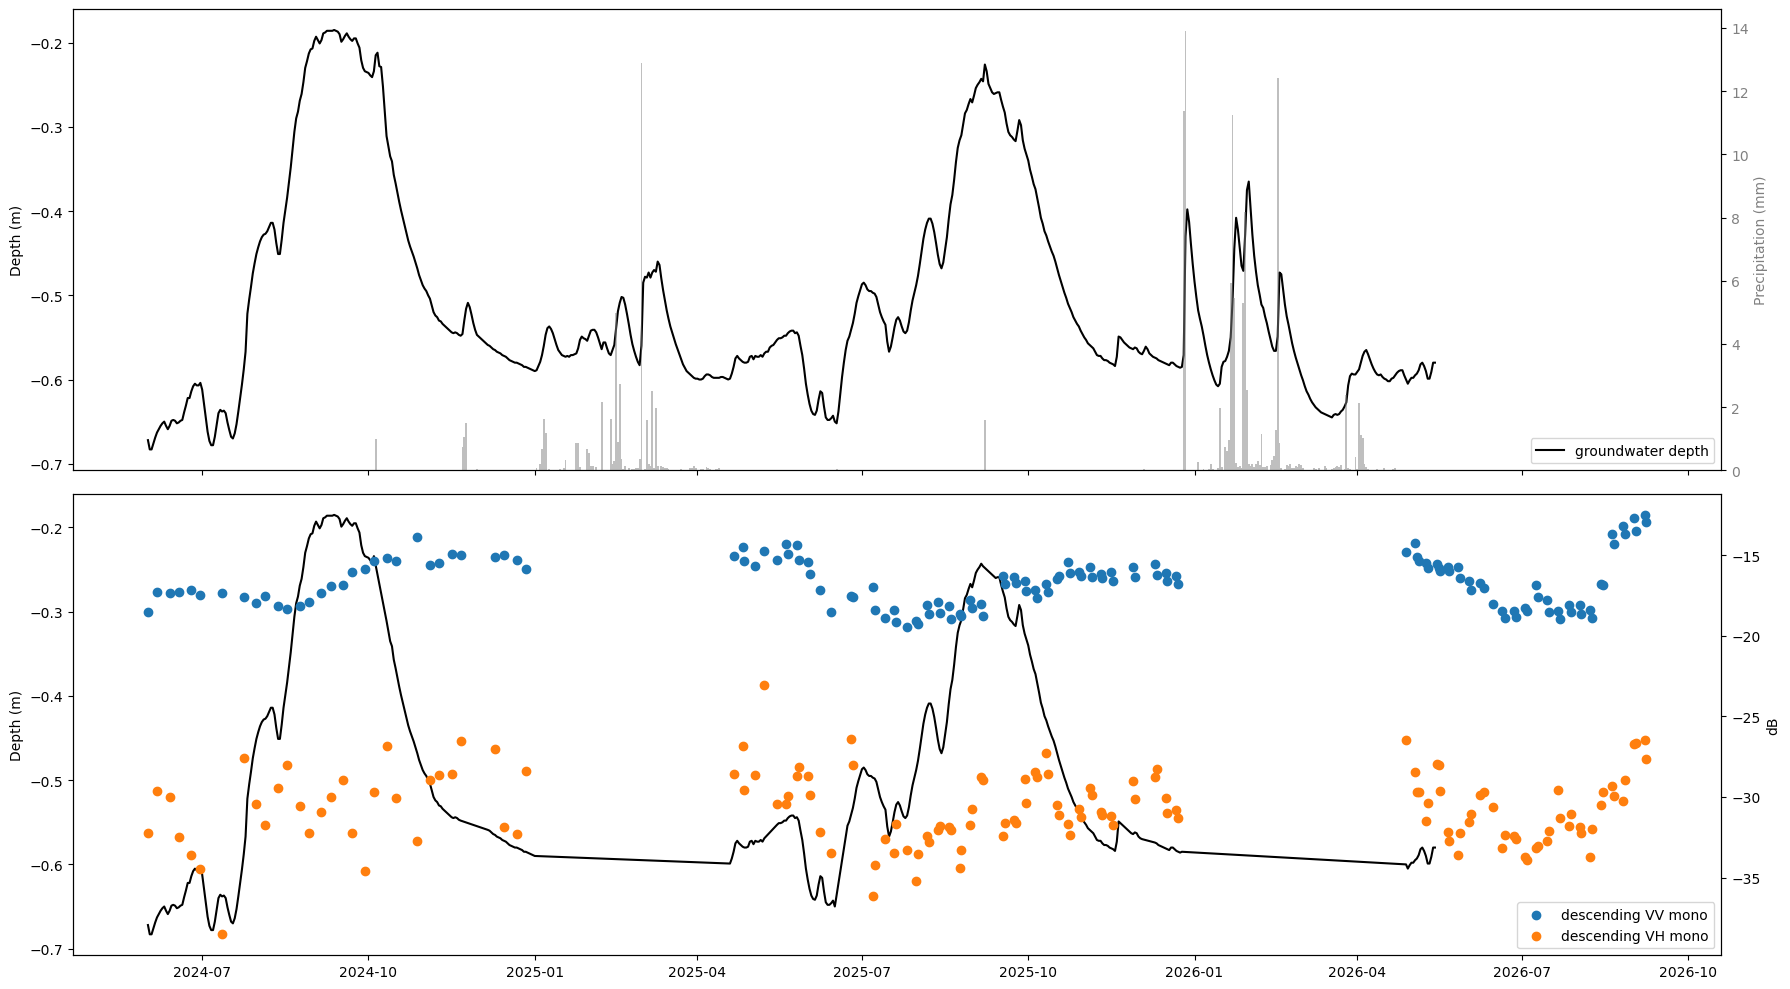

In [984]:
# Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot superior
ax1.plot(insitu.index, insitu['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax1.set_ylabel('Depth (m)')
ax1.legend(loc='lower right')

ax3 = ax1.twinx()
ax3.bar(insitu.index, insitu['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

# Plot inferior
ax2.plot(no_rain_df.index, no_rain_df['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax2.set_ylabel('Depth (m)')

ax4 = ax2.twinx()
ax4.scatter(no_rain_df.index, no_rain_df['VV_smooth'], label = 'descending VV mono')
ax4.scatter(no_rain_df.index, no_rain_df['VH_smooth'], label = 'descending VH mono')
ax4.legend(loc='lower right')
ax4.set_ylabel('dB')

plt.tight_layout()
plt.show()

#### Correlaciones cruzadas

In [985]:
def cross_corr_irregular(
    df_sar: pd.DataFrame,
    s_target: pd.Series,
    feature_cols: list[str],
    max_days_lag: int = 15,
    method: str = "pearson",
    min_samples: int = 15,
) -> pd.DataFrame:
    """Calcula la correlación cruzada entre adquisiciones SAR irregulares
    y una variable objetivo continua (ej. nivel freático diario).

    Parámetros:
    -----------
    df_sar : pd.DataFrame
        DataFrame con datos SAR (filtrado sin lluvias), con DatetimeIndex.
    s_target : pd.Series
        Serie temporal diaria continua del nivel freático, con DatetimeIndex.
    feature_cols : list[str]
        Bandas SAR a evaluar (ej. ['VV', 'VH', 'VV_smooth']).
    max_days_lag : int, default=15
        Ventana de desfase en días (+lag: SAR lidera; -lag: freático lidera).
    method : str, default='pearson'
        'pearson' o 'spearman' (recomendado si la relación freático-SAR no es estrictamente lineal).
    min_samples : int, default=15
        Mínimo de pares de datos requeridos para validar la correlación.

    Retorna:
    --------
    pd.DataFrame ordenado por |correlación| descendente.
    """
    results = []

    # Limpieza de índices temporales (normalizar a medianoche)
    sar_clean = df_sar[feature_cols].dropna(how="all").copy()
    sar_clean.index = sar_clean.index.normalize()

    target_clean = s_target.dropna().copy()
    target_clean.index = target_clean.index.normalize()

    for feature in feature_cols:
        feat_series = sar_clean[feature].dropna()

        for lag in range(-max_days_lag, max_days_lag + 1):
            # Proyectar las fechas SAR hacia la fecha de destino según el lag
            # lag > 0: Freático se evalúa días DESPUÉS del satélite (SAR antecede)
            # lag < 0: Freático se evalúa días ANTES del satélite
            shifted_dates = feat_series.index + pd.Timedelta(days=lag)

            # Extraer valores del nivel freático correspondientes a esas fechas proyectadas
            target_values = target_clean.reindex(shifted_dates)

            # Alinear los pares válidos (omite fechas caídas en máscaras de lluvia o vacíos)
            valid_mask = target_values.notna().values
            x = feat_series.values[valid_mask]
            y = target_values.values[valid_mask]

            n = len(x)
            if n >= min_samples:
                if method == "pearson":
                    r, p_val = stats.pearsonr(x, y)
                elif method == "spearman":
                    r, p_val = stats.spearmanr(x, y)
                else:
                    raise ValueError(
                        "Método no soportado. Usa 'pearson' o 'spearman'."
                    )
            else:
                r, p_val = np.nan, np.nan

            # Nomenclatura del desfase
            if lag > 0:
                direction = "sar_primero"  # SAR ocurre primero
            elif lag < 0:
                direction = "nivel_primero"  # Nivel freático ocurre primero
            else:
                direction = "same_day"

            results.append(
                {
                    "feature": feature,
                    "lag_days": lag,
                    "direction": direction,
                    "correlation": r,
                    "abs_correlation": abs(r) if pd.notnull(r) else 0.0,
                    "p_value": p_val,
                    "n_pairs": n,
                }
            )

    results_df = pd.DataFrame(results).sort_values(
        by=["feature", "abs_correlation"], ascending=[True, False]
    )

    return results_df.reset_index(drop=True)


In [986]:
cross_corr_no_rain = cross_corr_irregular(
    df_sar=no_rain_df,
    s_target=no_rain_df['SDH1PS01_gw-depth_m'],
    feature_cols=['VV', 'VH', 'VV_smooth', 'VH_smooth'],
    max_days_lag=80,
    method='spearman',
    min_samples=20
)

In [987]:
print(cross_corr_no_rain.groupby("feature").head(5))

       feature  lag_days      direction  correlation  abs_correlation  \
0           VH        74    sar_primero    -0.331911         0.331911   
1           VH        75    sar_primero    -0.315516         0.315516   
2           VH        78    sar_primero    -0.305877         0.305877   
3           VH        51    sar_primero    -0.298781         0.298781   
4           VH        56    sar_primero    -0.286603         0.286603   
161  VH_smooth        74    sar_primero    -0.459751         0.459751   
162  VH_smooth        49    sar_primero    -0.458382         0.458382   
163  VH_smooth       -70  nivel_primero     0.452097         0.452097   
164  VH_smooth       -69  nivel_primero     0.451203         0.451203   
165  VH_smooth        50    sar_primero    -0.450941         0.450941   
322         VV       -46  nivel_primero     0.488454         0.488454   
323         VV       -54  nivel_primero     0.482026         0.482026   
324         VV       -44  nivel_primero     0.48016

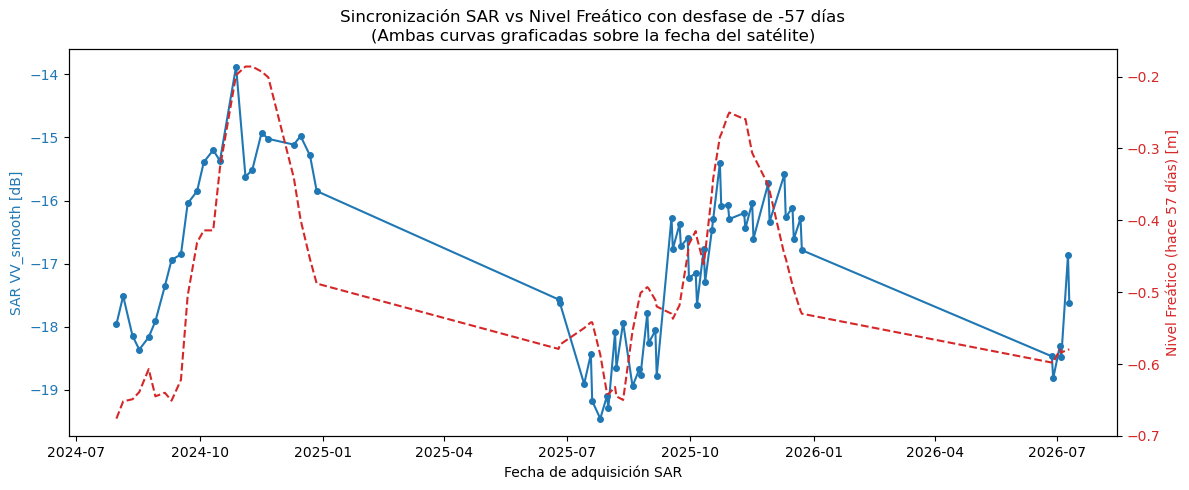

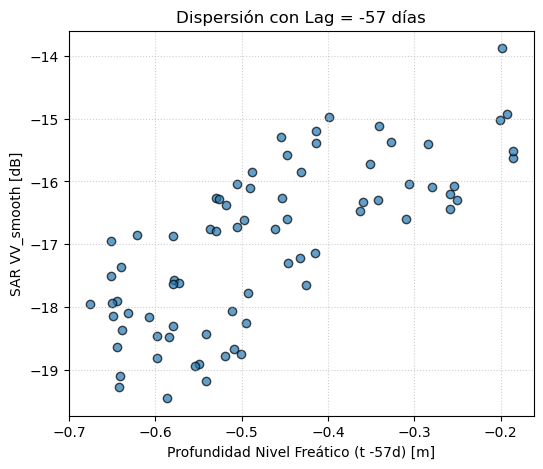

In [994]:
def get_aligned_lagged_data(df_sar, s_target, feature, lag_days):
    """Alinea temporalmente la serie SAR y el nivel freático según un lag específico (en días).

    Mantiene las fechas SAR como referencia temporal.
    """
    # 1. Limpieza y normalización de fechas a medianoche
    sar_series = df_sar[feature].dropna().copy()
    sar_series.index = sar_series.index.normalize()

    target_series = s_target.dropna().copy()
    target_series.index = target_series.index.normalize()

    # 2. Desplazar las fechas del freático para emparejar con la fecha SAR
    # Para lag = -57, buscamos el valor de target en (fecha_sar - 57 días)
    shifted_target_dates = sar_series.index + pd.Timedelta(days=lag_days)

    # 3. Muestrear el target en esas fechas desplazadas
    aligned_target = target_series.reindex(shifted_target_dates)
    aligned_target.index = (
        sar_series.index
    )  # Reasignar el índice de la fecha SAR

    # 4. Consolidar en un DataFrame
    df_plot = pd.DataFrame(
        {
            feature: sar_series,
            f"target_lag_{lag_days}d": aligned_target,
        }
    ).dropna()

    return df_plot


# ==========================================
# 1. Obtención de los datos alineados
# ==========================================
FEATURE = "VV_smooth"  # O la banda/feature que dio el mejor resultado
LAG = -57

df_lagged = get_aligned_lagged_data(
    df_sar=no_rain_df,
    s_target=no_rain_df["SDH1PS01_gw-depth_m"],
    feature=FEATURE,
    lag_days=LAG,
)

# ==========================================
# 2. Visualización de las series temporales
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 5))

# Eje 1: Señal de Radar (SAR)
color_sar = "tab:blue"
ax1.set_xlabel("Fecha de adquisición SAR")
ax1.set_ylabel(f"SAR {FEATURE} [dB]", color=color_sar)
line1 = ax1.plot(
    df_lagged.index,
    df_lagged[FEATURE],
    color=color_sar,
    marker="o",
    markersize=4,
    label=f"SAR ({FEATURE})",
)
ax1.tick_params(axis="y", labelcolor=color_sar)

# Eje 2: Nivel Freático (desfasado 57 días atrás)
ax2 = ax1.twinx()
color_gw = "tab:red"
ax2.set_ylabel(f"Nivel Freático (hace {-LAG} días) [m]", color=color_gw)
line2 = ax2.plot(
    df_lagged.index,
    df_lagged[f"target_lag_{LAG}d"],
    color=color_gw,
    linestyle="--",
    label=f"Freático (t {LAG}d)",
)
ax2.tick_params(axis="y", labelcolor=color_gw)

plt.title(
    f"Sincronización SAR vs Nivel Freático con desfase de {LAG} días\n(Ambas curvas graficadas sobre la fecha del satélite)"
)
fig.tight_layout()
plt.show()

# ==========================================
# 3. Diagrama de dispersión (Scatter Plot)
# ==========================================
plt.figure(figsize=(6, 5))
plt.scatter(
    df_lagged[f"target_lag_{LAG}d"],
    df_lagged[FEATURE],
    alpha=0.7,
    edgecolors="k",
)
plt.xlabel(f"Profundidad Nivel Freático (t {LAG}d) [m]")
plt.ylabel(f"SAR {FEATURE} [dB]")
plt.title(f"Dispersión con Lag = {LAG} días")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()


In [995]:
import numpy as np
from scipy import stats
from sklearn.metrics import r2_score

# 1. Extraer vectores (X: predictor, y: variable a estimar)
# Evaluamos cuánto explica el freático desfasado a la señal SAR (o viceversa)
x = df_lagged[f"target_lag_{LAG}d"].values
y = df_lagged[FEATURE].values

# 2. Ajuste lineal mediante scipy (proporciona pendiente, intercepto, r, p-value)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# En regresión lineal simple: R^2 = r^2
r2_pearson = r_value**2

# O mediante scikit-learn prediciendo el modelo ajustado:
y_pred = slope * x + intercept
r2_sklearn = r2_score(y, y_pred)

print(f"--- Resultados de Regresión (Lag = {LAG} días) ---")
print(f"R² (Coeficiente de determinación): {r2_sklearn:.4f}")
print(f"r de Pearson: {r_value:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"Ecuación: {FEATURE} = ({slope:.4f}) * Freático + ({intercept:.4f})")
print(f"Número de observaciones válidas (N): {len(x)}")


--- Resultados de Regresión (Lag = -57 días) ---
R² (Coeficiente de determinación): 0.5385
r de Pearson: 0.7338
p-value: 6.9108e-14
Ecuación: VV_smooth = (6.9383) * Freático + (-13.7276)
Número de observaciones válidas (N): 75


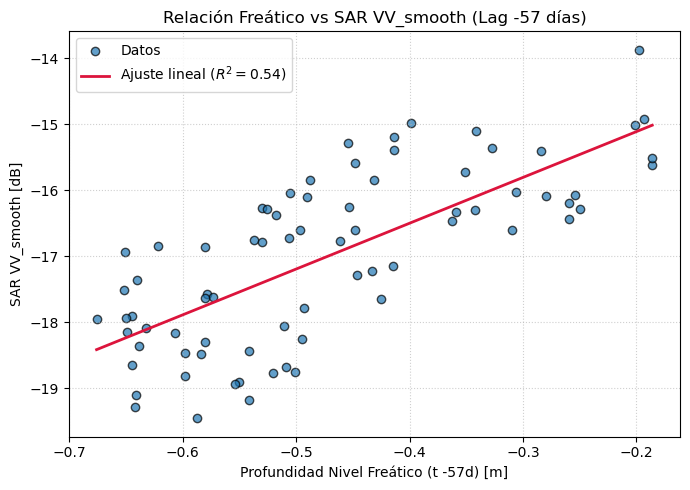

In [996]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# Puntos de dispersión
plt.scatter(x, y, color="tab:blue", edgecolors="k", alpha=0.7, label="Datos")

# Recta de ajuste
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(
    x_line,
    slope * x_line + intercept,
    color="crimson",
    linewidth=2,
    label=f"Ajuste lineal ($R^2 = {r2_sklearn:.2f}$)",
)

plt.xlabel(f"Profundidad Nivel Freático (t {LAG}d) [m]")
plt.ylabel(f"SAR {FEATURE} [dB]")
plt.title(f"Relación Freático vs SAR {FEATURE} (Lag {LAG} días)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()
